In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
import julia
from julia import Main
Main.eval("using QuadGK")
Main.eval('using Distributed')
Main.eval("using Roots")

In [3]:
Main.eval("""
    @everywhere begin
          
        using DelimitedFiles
        
        Grid1 = readdlm("../Grid/Γoverμ_1.csv", ',')
        Grid2 = readdlm("../Grid/Γoverμ_2.csv", ',')
        Grid3 = readdlm("../Grid/Γoverμ_3.csv", ',')
        Grid4 = readdlm("../Grid/Γoverμ_4.csv", ',')

        lnGrid1 = readdlm("../Grid/lnΓoverμ_1.csv", ',')
        lnGrid2 = readdlm("../Grid/lnΓoverμ_2.csv", ',')
        lnGrid3 = readdlm("../Grid/lnΓoverμ_3.csv", ',')
        lnGrid4 = readdlm("../Grid/lnΓoverμ_4.csv", ',')
          
        α1Grid = readdlm("../Grid/α1overμ.csv", ',')
        α2Grid = readdlm("../Grid/α2overμ.csv", ',')
        α3Grid = readdlm("../Grid/α3overμ.csv", ',')
        α4Grid = readdlm("../Grid/α4overμ.csv", ',')  
          
    end      
""")

Main.include("..\\strong coupling\\constants.jl")
Main.include("..\\strong coupling\\alpha_s.jl")
Main.include("..\\anomalous dim\\cusp\\cusp.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaH.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaB.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaS.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammav.jl")
Main.include("..\\hard\\hard.jl")
Main.include("..\\jet\\jet.jl")
Main.include("..\\soft\\soft.jl")
Main.include("..\\ζ-prescription.jl")
Main.include("..\\Grid\\interpolation.jl")
#Main.include("..\\sigma.jl")

In [4]:
result_set = {}
accuracies = ["bbstar_fit","bbstar_scan","log_fit","log_scan"]
for XLL in accuracies:
    result_set[XLL] = pd.read_csv("../result/"+XLL+".csv")

Import

In [5]:
import ast
def convert_to_list(string):
    corrected_string = string.replace("      ", ",")
    corrected_string = corrected_string.replace("     ", ",")
    corrected_string = corrected_string.replace("    ", ",") 
    corrected_string = corrected_string.replace("   ", ",") 
    corrected_string = corrected_string.replace("  ", ",")    
    corrected_string = corrected_string.replace(" ", ",")
    l=len(corrected_string)
    new_string=""
    for i in range(1,l-1):
        if (corrected_string[i]=="," and (corrected_string[i-1]=="[" or corrected_string[i+1]=="]")):
            new_string = new_string
        else:
            new_string = new_string + corrected_string[i]

    new_string = new_string + "]"
    new_string = "[" + new_string

    return ast.literal_eval(new_string)

αs_set = {}
a_set = {}

for XLL in accuracies:
    results_df = result_set[XLL]
    αs_set[XLL] = results_df['αs'].to_numpy()
    params = results_df['params'].apply(convert_to_list)
    params = np.array(params.to_list())

    rows = len(params)
    cols = len(params[0])
    a_list = {}

    for i in range(cols):
        a_list[i] = params[:,i]
            
    a_set[XLL] = pd.DataFrame(a_list)

    #print(a_list)

In [6]:
SV19_params = pd.read_csv("../data/SV19.csv")
SV19_BNP = SV19_params.iloc[:,0]
SV19_g2 = SV19_params.iloc[:,1]

bbstar_fit_αs = αs_set["bbstar_fit"]
bbstar_fit_g2 = a_set["bbstar_fit"].iloc[:,2]

bbstar_scan_αs = αs_set["bbstar_scan"]
bbstar_scan_g2 = a_set["bbstar_scan"].iloc[:,2]

log_fit_αs = αs_set["log_fit"]
log_fit_g2 = a_set["log_fit"].iloc[:,2]

log_scan_αs = αs_set["log_scan"]
log_scan_g2 = a_set["log_scan"].iloc[:,2]

In [7]:
SV19_params = [1.93,0.0427]

ART23_params = [1.56,0.0369,0.0582]
ART23_std_up = [0.13,0.0065,0.0064]
ART23_std_down = [0.09,0.0061,0.0088]

MAP22_params = [0.248]
MAP22_std = [0.008]

bbstar_params=[0.1173,0.087]
log_params=[0.1174,0.205]

In [8]:
def split_normal(mu, sigma_lower, sigma_upper, size):
    array=[]
    probs = sigma_lower / (sigma_lower + sigma_upper)
    for i in range(size):
        u = np.random.uniform(0, 1)
        if u < probs:
            value = mu-abs(np.random.normal(mu, sigma_lower)-mu)  
        else:
            value = mu+abs(np.random.normal(mu, sigma_upper)-mu)
        array.append(value)
    return np.array(array)

In [9]:
N_replicas=100

ART23_BNP = split_normal(ART23_params[0], ART23_std_down[0], ART23_std_up[0], N_replicas)
ART23_c0 = split_normal(ART23_params[1], ART23_std_down[1], ART23_std_up[1], N_replicas)
ART23_c1 = split_normal(ART23_params[2], ART23_std_down[2], ART23_std_up[2], N_replicas)

MAP22_g2 = np.random.normal(MAP22_params[0],MAP22_std[0],N_replicas)

Compute

In [10]:
length = 100
μ0 = 2.0
nf = 4

b0 = 1.12292
b_list = np.exp(np.linspace(np.log(10**(-3)),np.log(5),length))

SV19_central = np.zeros(length)
ART23_central = np.zeros(length)
MAP22_central = np.zeros(length)
bbstar_central = np.zeros(length)
log_central = np.zeros(length)

SV19_up = np.zeros(length)
SV19_down = np.zeros(length)

ART23_up = np.zeros(length)
ART23_down = np.zeros(length)

MAP22_up = np.zeros(length)
MAP22_down = np.zeros(length)

bbstar_fit_up = np.zeros(length)
bbstar_fit_down = np.zeros(length)

bbstar_scan_up = np.zeros(length)
bbstar_scan_down = np.zeros(length)

log_fit_up = np.zeros(length)
log_fit_down = np.zeros(length)

log_scan_up = np.zeros(length)
log_scan_down = np.zeros(length)

for index, bp in enumerate(b_list):

    D_list=[]
    BNP = SV19_params[0]
    c0 = SV19_params[1]
    bstar = bp/(1+(bp/BNP)**2)**0.5
    D = -1/4*Main.Integral_ν_numerical(b=bp, μf=μ0, αs_ini=0.118, μ_ini=91.1876, order=3, nf=nf, bmax=BNP) + c0*bp*bstar
    SV19_central[index] = D

    D_list=[]
    BNP = ART23_params[0]
    c0 = ART23_params[1]
    c1 = ART23_params[2]
    bstar = bp/(1+(bp/BNP)**2)**0.5
    D = -1/4*Main.Integral_ν_numerical(b=bp, μf=μ0, αs_ini=0.118, μ_ini=91.1876, order=4, nf=nf, bmax=BNP) + bp*bstar*(c0+c1*np.log(bstar/BNP))
    ART23_central[index] = D

    D_list=[]
    g2 = MAP22_params[0]
    D = -1/4*Main.Integral_ν_MAP22(b=bp, μf=μ0, αs_ini=0.118, μ_ini=91.1876, order=3, nf=nf, bmax=BNP) + 0.25*g2**2*bp**2
    MAP22_central[index] = D   

    D_list=[]
    αs_ini = bbstar_params[0]
    g2 = bbstar_params[1]
    bstar = bp/(1+(bp/b0)**2)**0.5
    D = -1/4*Main.Integral_ν_numerical(b=bp, μf=μ0, αs_ini=αs_ini, μ_ini=91.1876, order=3, nf=nf, bmax=b0) + g2*bp*bstar
    bbstar_central[index] = D

    D_list=[]
    αs_ini = log_params[0]
    g2 = log_params[1]
    bstar = bp/(1+(bp/b0)**2)**0.5
    D = -1/4*Main.Integral_ν_numerical(b=bp, μf=μ0, αs_ini=αs_ini, μ_ini=91.1876, order=3, nf=nf, bmax=b0) + g2*np.log(bp/bstar)
    log_central[index] = D 

for index, bp in enumerate(b_list):

    D_list=[]
    for i in range(length):
        BNP = SV19_BNP[i]
        c0 = SV19_g2[i]
        bstar = bp/(1+(bp/BNP)**2)**0.5
        D = -1/4*Main.Integral_ν_numerical(b=bp, μf=μ0, αs_ini=0.118, μ_ini=91.1876, order=3, nf=nf, bmax=BNP) + c0*bp*bstar
        D_list.append(D)
    
    SV19_up[index] = np.percentile(D_list,84)
    SV19_down[index] = np.percentile(D_list,16)

    D_list=[]
    for i in range(length):
        BNP = ART23_BNP[i]
        c0 = ART23_c0[i]
        c1 = ART23_c1[i]
        bstar = bp/(1+(bp/BNP)**2)**0.5
        D = -1/4*Main.Integral_ν_numerical(b=bp, μf=μ0, αs_ini=0.118, μ_ini=91.1876, order=4, nf=nf, bmax=BNP) + bp*bstar*(c0+c1*np.log(bstar/BNP))
        D_list.append(D)
    
    ART23_up[index] = np.percentile(D_list,84)
    ART23_down[index] = np.percentile(D_list,16)

    D_list=[]
    for i in range(length):
        g2 = MAP22_g2[i]
        D = -1/4*Main.Integral_ν_MAP22(b=bp, μf=μ0, αs_ini=0.118, μ_ini=91.1876, order=3, nf=nf, bmax=BNP) + 0.25*g2**2*bp**2
        D_list.append(D)
    
    MAP22_up[index] = np.percentile(D_list,84)
    MAP22_down[index] = np.percentile(D_list,16)

    D_list=[]
    for i in range(length):
        αs_ini = bbstar_fit_αs[i]
        g2 = bbstar_fit_g2[i]
        bstar = bp/(1+(bp/b0)**2)**0.5
        D = -1/4*Main.Integral_ν_numerical(b=bp, μf=μ0, αs_ini=αs_ini, μ_ini=91.1876, order=3, nf=nf, bmax=b0) + g2*bp*bstar
        D_list.append(D)
 
    bbstar_fit_up[index] = np.percentile(D_list,84)
    bbstar_fit_down[index] = np.percentile(D_list,16)

    D_list=[]
    for i in range(length):
        αs_ini = bbstar_scan_αs[i]
        g2 = bbstar_scan_g2[i]
        bstar = bp/(1+(bp/b0)**2)**0.5
        D = -1/4*Main.Integral_ν_numerical(b=bp, μf=μ0, αs_ini=αs_ini, μ_ini=91.1876, order=3, nf=nf, bmax=b0) + g2*bp*bstar
        D_list.append(D)
  
    bbstar_scan_up[index] = np.percentile(D_list,84)
    bbstar_scan_down[index] = np.percentile(D_list,16)
     
    D_list=[]
    for i in range(length):
        αs_ini = log_fit_αs[i]
        g2 = log_fit_g2[i]
        bstar = bp/(1+(bp/b0)**2)**0.5
        D = -1/4*Main.Integral_ν_numerical(b=bp, μf=μ0, αs_ini=αs_ini, μ_ini=91.1876, order=3, nf=nf, bmax=b0) + g2*np.log(bp/bstar)
        D_list.append(D)
  
    log_fit_up[index] = np.percentile(D_list,84)
    log_fit_down[index] = np.percentile(D_list,16)

    D_list=[]
    for i in range(length):
        αs_ini = log_scan_αs[i]
        g2 = log_scan_g2[i]
        bstar = bp/(1+(bp/b0)**2)**0.5
        D = -1/4*Main.Integral_ν_numerical(b=bp, μf=μ0, αs_ini=αs_ini, μ_ini=91.1876, order=3, nf=nf, bmax=b0) + g2*np.log(bp/bstar)
        D_list.append(D)

    log_scan_up[index] = np.percentile(D_list,84)
    log_scan_down[index] = np.percentile(D_list,16)

Plot

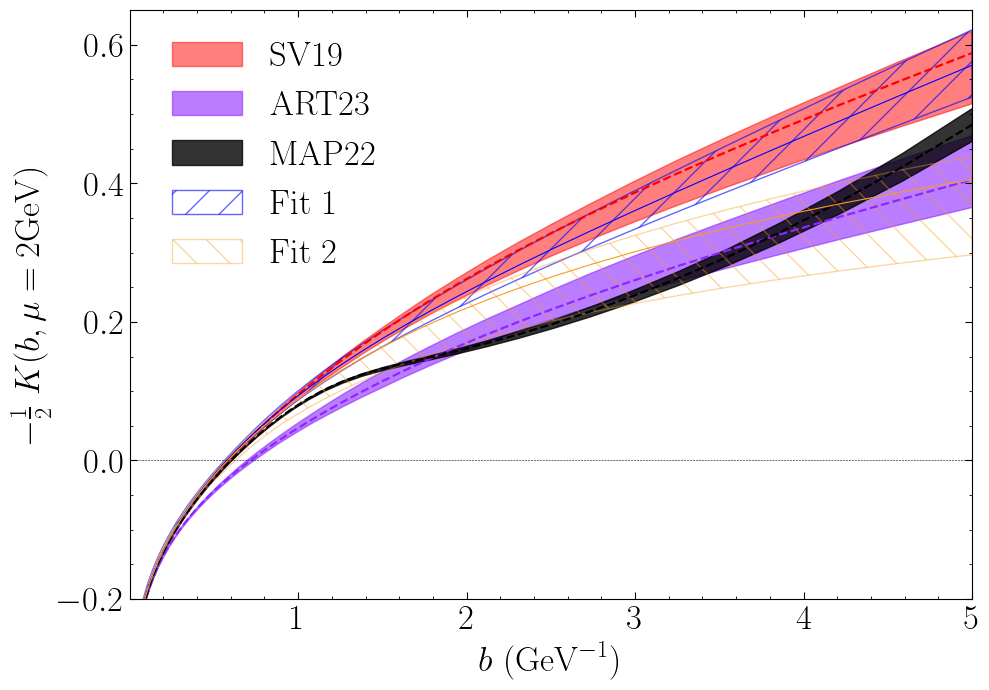

In [11]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 7)) 

#color = ["red","orange","purple","green","teal"]
#blue=(87/255,144/255,252/255)
#orange=(248/255,156/255,32/255)
#red=(228/255,37/255,54/255)
#purple1=(150/255,74/255,139/255)
#gray=(156/255,156/255,161/255)
#purple1=(122/255,33/255,221/255)

blue=(87/255,144/255,252/255)
blue=(0,0,1)
red=(1,0,0)
orange=(248/255,156/255,32/255)
#red=(228/255,37/255,54/255)
purple1=(150/150,74/150,139/150)
gray=(156/161,156/161,161/161)
purple2=(122/221,33/221,221/221)

color = [red,purple2,"black",blue,orange]

props = dict(boxstyle='round', facecolor='white', alpha=0)
sizeOfFont= 25
sizeOfTick = 25
widthOfLine = 0.8
transOfBands = 0.6

ax1.plot(b_list, SV19_central, color=color[0], lw=2*widthOfLine, linestyle='dashed')
ax1.fill_between(b_list, SV19_down, SV19_up, alpha=0.5, color=color[0], label=r"\rm $ \rm{SV19}$")

ax1.plot(b_list, ART23_central, color=color[1], lw=2*widthOfLine, linestyle='dashed')
ax1.fill_between(b_list, ART23_down, ART23_up, alpha=transOfBands, color=color[1], label=r"\rm $ \rm{ART23}$")

ax1.plot(b_list, MAP22_central, color=color[2], lw=2*widthOfLine, linestyle='dashed')
ax1.fill_between(b_list, MAP22_down, MAP22_up, alpha=0.8, color=color[2], label=r"\rm $ \rm{MAP22}$")

ax1.plot(b_list, bbstar_central, color=color[3], lw=widthOfLine)
#ax1.fill_between(b_list, bbstar_fit_down, bbstar_fit_up, alpha=0.3, color=color[3], label=r"\rm $ \rm{Fit} \ 1$")
ax1.fill_between(b_list, bbstar_fit_down, bbstar_fit_up, alpha=0.6, color="None", hatch="/",edgecolor=color[3], label=r"\rm $ \rm{Fit} \ 1$")
#ax1.fill_between(b_list, bbstar_scan_down, bbstar_scan_up, alpha=0.4, color=color[3])

ax1.plot(b_list, log_central, color=color[4], lw=widthOfLine)
#ax1.fill_between(b_list,log_fit_down,log_fit_up, alpha=0.3, color=color[4], label=r"\rm $ \rm{Fit} \ 2$")
ax1.fill_between(b_list,log_fit_down,log_fit_up, alpha=0.4, color="None", edgecolor=color[4], hatch='\\', label=r"\rm $ \rm{Fit} \ 2$")
#ax1.fill_between(b_list, log_scan_down, log_scan_up, alpha=transOfBands,color=color[4])

ax1.axhline(0.0, color='black', linestyle='--', linewidth=0.5*widthOfLine)

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.33, 1))
ax1.set_xlim(0,5)
ax1.set_xticks([1.0,2.0,3.0,4.0,5.0])
ax1.set_ylim(-0.2,0.65)
ax1.set_yticks([-0.2,0.0,0.2,0.4,0.6])

ax1.set_xlabel(r"\rm $ b \ (\text{GeV}^{-1}) $", fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $ - \frac{1}{2} \ K(b,\mu=2 \rm{GeV}) $", fontsize=sizeOfFont)

plt.tight_layout()  
plt.show()

fig.savefig('CS.pdf')

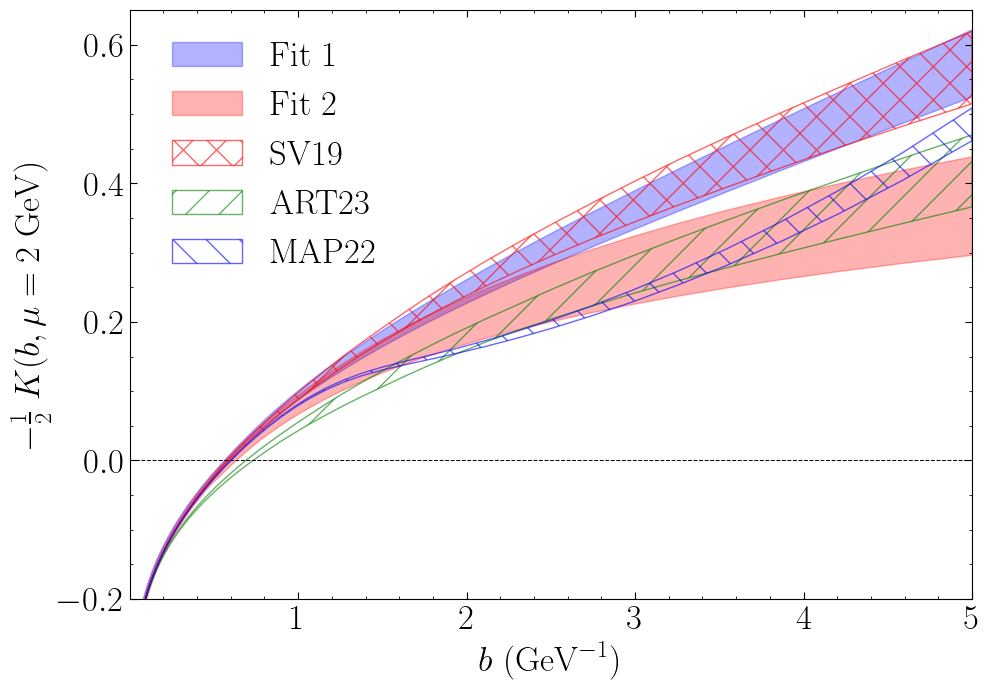

In [12]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 7)) 

blue=(87/255,144/255,252/255)
blue=(0,0,1)
red=(1,0,0)
orange=(248/255,156/255,32/255)
#red=(228/255,37/255,54/255)
purple1=(150/150,74/150,139/150)
gray=(156/161,156/161,161/161)
purple2=(122/221,33/221,221/221)

#color = [red,purple2,"black",blue,"red"]
color = [red,"green","blue",blue,"red"]

props = dict(boxstyle='round', facecolor='white', alpha=0)
sizeOfFont= 25
sizeOfTick = 25
widthOfLine = 1.5
transOfBands = 0.3
transOfHatch = 0.6

#ax1.plot(b_list, bbstar_central, color=color[3], lw=widthOfLine)
ax1.fill_between(b_list, bbstar_fit_down, bbstar_fit_up, alpha=transOfBands, color=color[3], label=r"\rm $ \rm{Fit} \ 1$")

#ax1.plot(b_list, log_central, color=color[4], lw=widthOfLine)
ax1.fill_between(b_list,log_fit_down,log_fit_up, alpha=transOfBands, color=color[4], label=r"\rm $ \rm{Fit} \ 2$")

#ax1.plot(b_list, SV19_central, color=color[0], lw=widthOfLine, linestyle='dashed')
ax1.fill_between(b_list, SV19_down, SV19_up, alpha=transOfHatch, color="None", label=r"\rm $ \rm{SV19}$", hatch="x",edgecolor=color[0])

#ax1.plot(b_list, ART23_central, color=color[1], lw=widthOfLine, linestyle='dashed')
ax1.fill_between(b_list, ART23_down, ART23_up, alpha=transOfHatch, color="None", label=r"\rm $ \rm{ART23}$", hatch="/",edgecolor=color[1])

#ax1.plot(b_list, MAP22_central, color=color[2], lw=widthOfLine, linestyle='dashed')
ax1.fill_between(b_list, MAP22_down, MAP22_up, alpha=transOfHatch, color="None", label=r"\rm $ \rm{MAP22}$", hatch='\\',edgecolor=color[2])

ax1.axhline(0.0, color='black', linestyle='--', linewidth=0.5*widthOfLine)

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.33, 1))
ax1.set_xlim(0,5)
ax1.set_xticks([1.0,2.0,3.0,4.0,5.0])
ax1.set_ylim(-0.2,0.65)
ax1.set_yticks([-0.2,0.0,0.2,0.4,0.6])

ax1.set_xlabel(r"\rm $ b \ (\text{GeV}^{-1}) $", fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $ - \frac{1}{2} \ K(b,\mu=2 \ \rm{GeV}) $", fontsize=sizeOfFont)

plt.tight_layout()  
plt.show()

fig.savefig('CS.pdf')

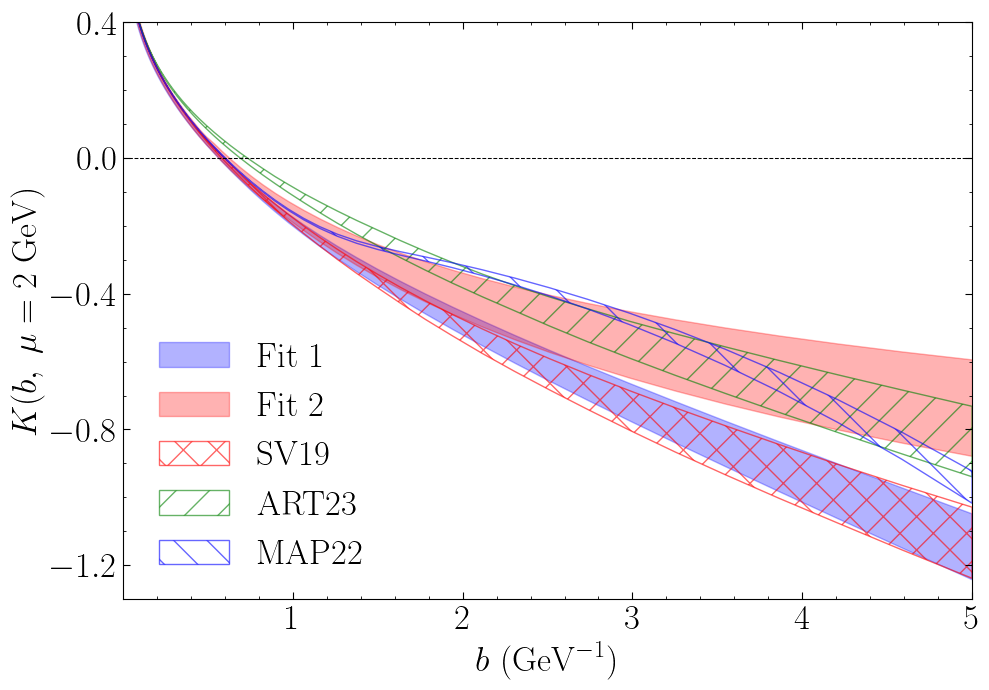

In [27]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 7)) 

blue=(87/255,144/255,252/255)
blue=(0,0,1)
red=(1,0,0)
orange=(248/255,156/255,32/255)
#red=(228/255,37/255,54/255)
purple1=(150/150,74/150,139/150)
gray=(156/161,156/161,161/161)
purple2=(122/221,33/221,221/221)

#color = [red,purple2,"black",blue,"red"]
color = [red,"green","blue",blue,"red"]

props = dict(boxstyle='round', facecolor='white', alpha=0)
sizeOfFont= 25
sizeOfTick = 25
widthOfLine = 1.5
transOfBands = 0.3
transOfHatch = 0.6

#ax1.plot(b_list, bbstar_central, color=color[3], lw=widthOfLine)
ax1.fill_between(b_list, -2*bbstar_fit_down, -2*bbstar_fit_up, alpha=transOfBands, color=color[3], label=r"\rm $ \rm{Fit} \ 1$")

#ax1.plot(b_list, log_central, color=color[4], lw=widthOfLine)
ax1.fill_between(b_list, -2*log_fit_down, -2*log_fit_up, alpha=transOfBands, color=color[4], label=r"\rm $ \rm{Fit} \ 2$")

#ax1.plot(b_list, SV19_central, color=color[0], lw=widthOfLine, linestyle='dashed')
ax1.fill_between(b_list, -2*SV19_down, -2*SV19_up, alpha=transOfHatch, color="None", label=r"\rm $ \rm{SV19}$", hatch="x",edgecolor=color[0])

#ax1.plot(b_list, ART23_central, color=color[1], lw=widthOfLine, linestyle='dashed')
ax1.fill_between(b_list, -2*ART23_down, -2*ART23_up, alpha=transOfHatch, color="None", label=r"\rm $ \rm{ART23}$", hatch="/",edgecolor=color[1])

#ax1.plot(b_list, MAP22_central, color=color[2], lw=widthOfLine, linestyle='dashed')
ax1.fill_between(b_list, -2*MAP22_down, -2*MAP22_up, alpha=transOfHatch, color="None", label=r"\rm $ \rm{MAP22}$", hatch='\\',edgecolor=color[2])

ax1.axhline(0.0, color='black', linestyle='--', linewidth=0.5*widthOfLine)

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.32, 0.5))
ax1.set_xlim(0,5)
ax1.set_xticks([1.0,2.0,3.0,4.0,5.0])
ax1.set_ylim(-1.3,0.4)
ax1.set_yticks([0.4,0.0,-0.4,-0.8,-1.2])

ax1.set_xlabel(r"\rm $ b \ (\text{GeV}^{-1}) $", fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $ K(b, \ \mu=2 \ \rm{GeV}) $", fontsize=sizeOfFont)

plt.tight_layout()  
plt.show()

fig.savefig('CS.pdf')